# Sketching in ML: Inner-Product Preservation (Gaussian Random Projections)

This notebook demonstrates empirically that a Gaussian sketch matrix \(S \in \mathbb{R}^{m \times n}\) preserves inner products as the sketch dimension \(m\) grows.

**Sketch definition.** We use entries
\[
s_{ij} \stackrel{\text{i.i.d.}}{\sim} \mathcal{N}\!\left(0,\frac{1}{m}\right),
\]
equivalently, \(S = \frac{1}{\sqrt{m}}\,G\) with \(G_{ij}\sim \mathcal{N}(0,1)\). For vectors \(x,y\in\mathbb{R}^n\), we compare the true inner product \(\langle x,y\rangle\) and the sketched one \(\langle Sx, Sy\rangle\).

We show:
- **Bulk behavior:** average errors shrink with \(m\).
- **Single-pair concentration:** for a fixed pair, estimates concentrate around the truth as \(m\) increases.

This aligns with Johnson–Lindenstrauss–style guarantees.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Matplotlib inline display (when running in Jupyter)
%matplotlib inline

# Reproducibility
rng = np.random.default_rng(42)

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


NumPy: 1.26.4
Pandas: 2.2.1


## Step 1 — Generate synthetic vector pairs with varied angles

We sample \(k\) pairs \((x_i, y_i)\) in \(\mathbb{R}^n\) with a spread of correlations \(\rho \in [-0.9, 0.9]\) via
\[
y = \rho\,x + \sqrt{1-\rho^2}\,z,\quad x,z \sim \mathcal{N}(0, I_n).
\]


In [5]:
# Ambient dimension, #pairs, and sketch sizes
n = 800
k = 400
m_list = [10, 20, 50, 100, 200, 400, 800]

# Sample correlations across a wide range
rhos = rng.uniform(-0.9, 0.9, size=k)

# Build pairs
X = rng.normal(0, 1, size=(k, n))
Z = rng.normal(0, 1, size=(k, n))
Y = np.empty_like(X)

for i, rho in enumerate(rhos):
    Y[i] = rho * X[i] + np.sqrt(max(0.0, 1 - rho**2)) * Z[i]

# Ground-truth inner products and cosines
dot_true = np.einsum('ij,ij->i', X, Y)
normX = np.linalg.norm(X, axis=1)
normY = np.linalg.norm(Y, axis=1)
cos_true = dot_true / (normX * normY)


## Step 2 — Define the Gaussian sketch and metric helpers

In [6]:
def gaussian_sketch(m, n, rng):
    # Entries ~ N(0, 1/m)  ==> rows ~ N(0, I)/sqrt(m)
    return rng.normal(0.0, 1.0/np.sqrt(m), size=(m, n))

def sketched_metrics(X, Y, m, rng):
    S = gaussian_sketch(m, X.shape[1], rng)
    Xp = X @ S.T     # shape (k, m)
    Yp = Y @ S.T
    dot_hat = np.einsum('ij,ij->i', Xp, Yp)
    cos_hat = dot_hat / (np.linalg.norm(Xp, axis=1) * np.linalg.norm(Yp, axis=1))
    return dot_hat, cos_hat


## Step 3 — Bulk evaluation: errors vs sketch dimension \(m\)

We average absolute and RMSE errors over multiple independently sampled sketches.


In [7]:
replicates_bulk = 4

rows = []
for m in m_list:
    mae_dot_accum = 0.0
    rmse_dot_accum = 0.0
    mae_cos_accum = 0.0
    rmse_cos_accum = 0.0

    for _ in range(replicates_bulk):
        dot_hat, cos_hat = sketched_metrics(X, Y, m, rng)
        err_dot = dot_hat - dot_true
        err_cos = cos_hat - cos_true
        mae_dot_accum += np.mean(np.abs(err_dot))
        rmse_dot_accum += np.sqrt(np.mean(err_dot**2))
        mae_cos_accum += np.mean(np.abs(err_cos))
        rmse_cos_accum += np.sqrt(np.mean(err_cos**2))

    rows.append({
        "m (sketch dim)": m,
        "MAE[<Sx,Sy> - <x,y>]": mae_dot_accum / replicates_bulk,
        "RMSE[<Sx,Sy> - <x,y>]": rmse_dot_accum / replicates_bulk,
        "MAE[cos(Sx,Sy) - cos(x,y)]": mae_cos_accum / replicates_bulk,
        "RMSE[cos(Sx,Sy) - cos(x,y)]": rmse_cos_accum / replicates_bulk,
    })

bulk_df = pd.DataFrame(rows)
bulk_df


,m (sketch dim),"MAE[<Sx,Sy> - <x,y>]","RMSE[<Sx,Sy> - <x,y>]","MAE[cos(Sx,Sy) - cos(x,y)]","RMSE[cos(Sx,Sy) - cos(x,y)]"
0,10,221.393232,288.657238,0.192005,0.253805
1,20,163.106445,209.865767,0.135281,0.177407
2,50,102.595091,128.026185,0.085967,0.112921
3,100,69.029910,86.011942,0.058747,0.077387
4,200,49.956136,62.222436,0.041393,0.054430
5,400,34.973147,44.163723,0.028504,0.037535
6,800,24.615760,30.968606,0.020800,0.027312


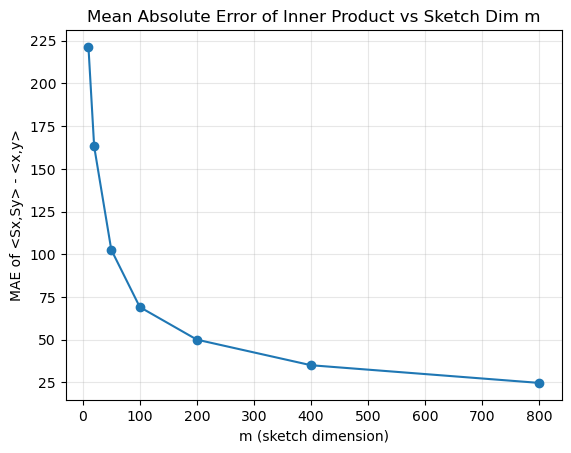

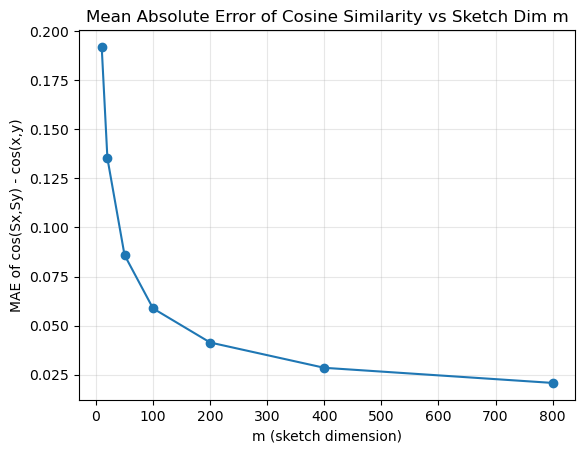

In [8]:
# Plot MAE of inner product vs m
plt.figure()
plt.plot(bulk_df["m (sketch dim)"], bulk_df["MAE[<Sx,Sy> - <x,y>]"], marker="o")
plt.title("Mean Absolute Error of Inner Product vs Sketch Dim m")
plt.xlabel("m (sketch dimension)")
plt.ylabel("MAE of <Sx,Sy> - <x,y>")
plt.grid(True, alpha=0.3)
plt.show()

# Plot MAE of cosine vs m
plt.figure()
plt.plot(bulk_df["m (sketch dim)"], bulk_df["MAE[cos(Sx,Sy) - cos(x,y)]"], marker="o")
plt.title("Mean Absolute Error of Cosine Similarity vs Sketch Dim m")
plt.xlabel("m (sketch dimension)")
plt.ylabel("MAE of cos(Sx,Sy) - cos(x,y)")
plt.grid(True, alpha=0.3)
plt.show()


## Step 4 — Single-pair concentration with error bars

We fix a pair with correlation \(\rho\approx 0.6\) and repeat sketching many times per \(m\) to visualize concentration around the true value.


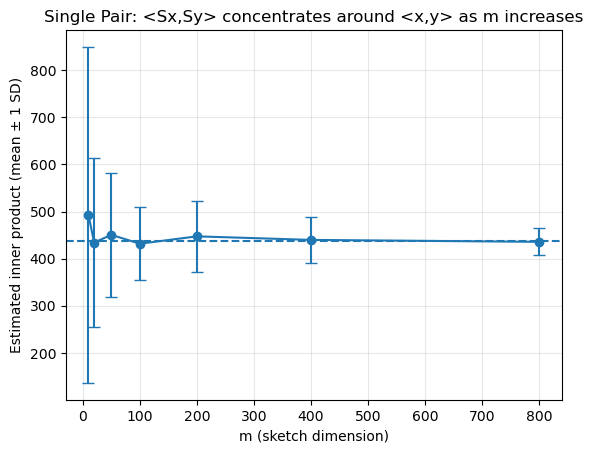

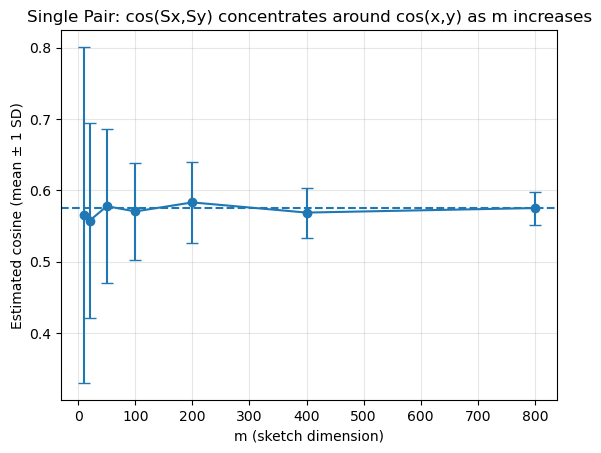

In [9]:
# Build a single pair with target rho=0.6
x0 = rng.normal(0, 1, size=n)
z0 = rng.normal(0, 1, size=n)
rho = 0.6
y0 = rho * x0 + np.sqrt(1 - rho**2) * z0

dot0 = float(x0 @ y0)
cos0 = float(dot0 / (np.linalg.norm(x0) * np.linalg.norm(y0)))

single_pair_reps = 40  # keep modest for quick execution

means_dot, stds_dot, means_cos, stds_cos = [], [], [], []
for m in m_list:
    dots, coss = [], []
    for _ in range(single_pair_reps):
        S = gaussian_sketch(m, n, rng)
        xP = S @ x0
        yP = S @ y0
        d = float(np.dot(xP, yP))
        c = float(d / (np.linalg.norm(xP) * np.linalg.norm(yP)))
        dots.append(d); coss.append(c)
    means_dot.append(np.mean(dots)); stds_dot.append(np.std(dots, ddof=1))
    means_cos.append(np.mean(coss)); stds_cos.append(np.std(coss, ddof=1))

# Error-bar plots
plt.figure()
plt.errorbar(m_list, means_dot, yerr=stds_dot, fmt='o-', capsize=4)
plt.axhline(dot0, linestyle='--')
plt.title("Single Pair: <Sx,Sy> concentrates around <x,y> as m increases")
plt.xlabel("m (sketch dimension)"); plt.ylabel("Estimated inner product (mean ± 1 SD)")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
plt.errorbar(m_list, means_cos, yerr=stds_cos, fmt='o-', capsize=4)
plt.axhline(cos0, linestyle='--')
plt.title("Single Pair: cos(Sx,Sy) concentrates around cos(x,y) as m increases")
plt.xlabel("m (sketch dimension)"); plt.ylabel("Estimated cosine (mean ± 1 SD)")
plt.grid(True, alpha=0.3)
plt.show()


## Step 5 — Recap

- We used a Gaussian sketch \(S\) with entries \( \mathcal{N}(0,1/m)\).
- As \(m\) increases, average errors of both inner product and cosine shrink.
- For a fixed pair, the estimator concentrates around the true value with variance that decays like \(1/m\).
